In [ ]:
from google.colab import files
uploaded = files.upload()


Saving customers.xlsx to customers.xlsx


Saving customers.xlsx to customers (1).xlsx
       ID  Gender Ever_Married  Age Graduated     Profession  Work_Experience  \
0  462809    Male           No   22        No     Healthcare                1   
1  462643  Female          Yes   38       Yes       Engineer                3   
2  466315  Female          Yes   67       Yes       Engineer                1   
3  461735    Male          Yes   67       Yes         Lawyer                0   
4  462669  Female          Yes   40       Yes  Entertainment                6   

  Spending_Score  Family_Size  Var_1 Segmentation  
0            Low            4  Cat_4            D  
1        Average            3  Cat_4            A  
2            Low            1  Cat_6            B  
3           High            2  Cat_6            B  
4           High            6  Cat_6            A  

Columns:
 Index(['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
       'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1',
     

/tmp/ipython-input-1525172517.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipython-input-1525172517.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

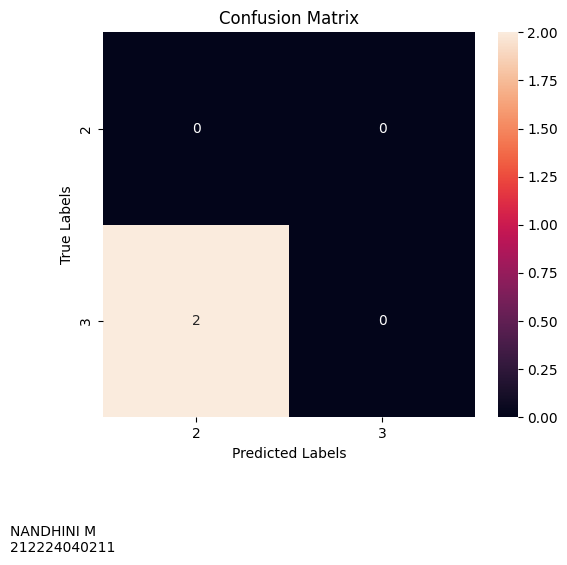


NAME: NANDHINI M
REG NO: 212224040211

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           2       0.00      0.00      0.00       1.0
           3       0.00      0.00      0.00       2.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0


New Sample Data Prediction
NAME: NANDHINI M
REG NO: 212224040211
Predicted class for sample input: 0
Actual class for sample input: 2


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [ ]:
# ================= INSTALL & IMPORT =================
!pip install pandas scikit-learn openpyxl matplotlib seaborn torch -q

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# ================= UPLOAD DATASET =================
from google.colab import files
uploaded = files.upload()   # upload customers.xlsx

# ================= LOAD DATA =================
df = pd.read_excel("customers.xlsx")

print(df.head())
print("\nColumns:\n", df.columns)

# ================= DATA PREPROCESSING =================

df = df.drop(columns=["ID"])   # remove ID column

# fill missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

# encode categorical columns
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# features & target
X = df.drop("Segmentation", axis=1).values
y = df["Segmentation"].values

# scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

# ================= MODEL =================
class PeopleClassifier(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 4)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

model = PeopleClassifier(X_train.shape[1])

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ================= TRAIN MODEL =================
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/100], Loss: {loss.item():.4f}')

# ================= EVALUATION =================
model.eval()
with torch.no_grad():
    outputs = model(X_test)
    _, preds = torch.max(outputs, 1)

# ================= CONFUSION MATRIX =================
labels = np.unique(y_test)
cm = confusion_matrix(y_test, preds, labels=labels)

print("\nNAME: NANDHINI M")
print("REG NO: 212224040211")

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")

plt.text(-0.5, len(labels)+0.7,
         "NANDHINI M\n212224040211",
         fontsize=10)

plt.show()

# ================= CLASSIFICATION REPORT =================
print("\nNAME: NANDHINI M")
print("REG NO: 212224040211\n")

print("Classification Report:\n")
print(classification_report(y_test, preds))

# ================= SAMPLE PREDICTION =================
sample_index = 0   # choose any row from test set
sample = X_test[sample_index].unsqueeze(0)

with torch.no_grad():
    prediction = model(sample)
    predicted_class = torch.argmax(prediction, 1).item()
    actual_class = y_test[sample_index].item()

print("\nNew Sample Data Prediction")
print("NAME: NANDHINI M")
print("REG NO: 212224040211")
print(f"Predicted class for sample input: {predicted_class}")
print(f"Actual class for sample input: {actual_class}")
